# Image Generation Benchmark: OpenAI vs xAI (DeepSeek & Claude noted as unsupported)

**Important reality check before you run this:**

| Provider | Image generation API? | Notes |
|---|---|---|
| OpenAI | ✅ Yes | `gpt-image-1` / DALL·E 3 via `images.generate` |
| xAI (Grok) | ✅ Yes | `grok-2-image` via Grok's `images.generate`-compatible endpoint |
| DeepSeek | ❌ No | DeepSeek currently only exposes text/code/reasoning models — no image generation endpoint exists as of this writing |
| Anthropic (Claude) | ❌ No | Claude can *understand/describe* images (vision input) but has no image-*generation* API |

This notebook therefore benchmarks **OpenAI vs xAI** for real, and includes clearly-labeled stub functions for DeepSeek/Claude so you can drop in support later if/when they ship image generation — without that, any "comparison" including them would be fabricated.

It compares:
- **Quality proxies** (no ground truth exists for "realism", so we use objective, reproducible proxies): sharpness (Laplacian variance), colorfulness, resolution, and CLIP-based prompt↔image alignment score
- **Latency** (wall-clock per generation call)
- **Token/unit usage** (prompt tokens where applicable; image pixel-count as the billing unit for image APIs, which bill per-image/per-resolution rather than per-token)
- **Cost** (USD, computed from each provider's published pricing — update the `PRICING` dict if rates change)


In [61]:
%pip install --quiet openai requests pillow opencv-python-headless numpy pandas matplotlib torch torchvision ftfy regex tqdm git+https://github.com/openai/CLIP.git


Note: you may need to restart the kernel to use updated packages.


In [62]:
# === 0. Setup ===
import os, io, time, json, base64
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
from dotenv import load_dotenv


# Load API keys from API_KEY.txt if it exists
if os.path.exists("API_KEY.txt"):
    with open("API_KEY.txt", "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                key, val = line.split("=", 1)
                os.environ[key.strip()] = val.strip()

load_dotenv()

# Set your API keys as environment variables (don't hardcode secrets in the notebook)
ANTHROPIC_API_KEY = os.getenv("ANTHROPIC_API_KEY", "")
OPENAI_API_KEY    = os.getenv("OPENAI_API_KEY",    "")
DEEPSEEK_API_KEY  = os.getenv("DEEPSEEK_API_KEY",  "")
XAI_API_KEY       = os.getenv("XAI_API_KEY",       "")

OUT_DIR = "generated_images"
os.makedirs(OUT_DIR, exist_ok=True)


In [63]:
# === 1. Prompts to test (kept identical across providers for a fair comparison) ===
# PROMPTS = [
#     "A photorealistic real-life Charizard standing on a volcanic mountain at sunset, orange dragon-like body, large wings, flame burning at the tip of its tail, cinematic lighting, highly detailed scales",

#     "A photorealistic real-life Nidoking in a rocky desert, powerful purple rhinoceros-like monster with a large horn, armored skin, muscular body, dramatic natural lighting, highly detailed texture",

#     "A photorealistic real-life Gardevoir standing in a misty forest, elegant humanoid fairy-like creature, white and green flowing form, calm expression, soft magical lighting, cinematic depth of field",

#     "A photorealistic real-life Arceus standing in a cosmic ancient temple, majestic white mythical creature with gold ring-like structure around its body, divine atmosphere, glowing light, ultra detailed",

#     "A photorealistic real-life Pikachu sitting in a grassy field, small yellow electric mouse-like creature, red cheeks, long ears with black tips, cute expression, natural daylight, shallow depth of field",
# ]

PROMPTS = [
    "A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",

    "A photorealistic real-life petite anime-inspired mage girl with long pink hair, emerald green eyes, wearing a detailed fantasy robe and carrying a glowing magic staff, standing in an enchanted forest with soft morning fog, ultra realistic, cinematic composition, highly detailed textures",

    "A photorealistic real-life anime-inspired shrine maiden with long black hair and red ribbon, wearing a traditional white and red shrine outfit, standing in front of a Japanese shrine during autumn, golden hour lighting, realistic photography, extremely detailed",

    "A photorealistic real-life anime-inspired elf girl with short platinum hair and violet eyes, wearing intricate fantasy armor, standing on ancient castle ruins under moonlight, cinematic lighting, ultra detailed, realistic skin and fabric textures",

    "A photorealistic real-life cute anime-inspired adventurer girl with short blonde hair, blue eyes, wearing leather explorer clothing and a small backpack, standing beside a crystal lake surrounded by mountains, natural daylight, highly realistic photography, cinematic depth of field"
]


In [64]:
# === 2. Pricing table (USD) — UPDATE THESE if provider pricing changes ===
# Image APIs bill per image at a given resolution/quality tier rather than per output token,
# so "token cost" below reflects (a) prompt tokens billed as text input where applicable, and
# (b) the per-image generation charge, which we treat as the dominant cost driver.

PRICING = {
    "openai_gpt-image-1": {
        "input_text_per_1k_tokens": 0.005,   # prompt tokens, text modality
        "per_image_1024x1024": 0.040,        # standard quality, 1024x1024
    },
    "xai_grok-2-image": {
        "input_text_per_1k_tokens": 0.0,     # xAI does not separately bill prompt tokens for image calls
        "per_image": 0.07,                   # flat per-image rate
    },
}


In [65]:
%pip install tiktoken

Note: you may need to restart the kernel to use updated packages.


In [66]:
# === 3. Token counting helper (prompt tokens only — output is an image, not tokens) ===
import tiktoken

def count_prompt_tokens(prompt, model="gpt-4o"):
    try:
        enc = tiktoken.encoding_for_model(model)
    except Exception:
        enc = tiktoken.get_encoding("cl100k_base")
    return len(enc.encode(prompt))


In [67]:
# === 4. Provider call wrappers ===

def gen_openai(prompt, size="1024x1024"):
    """Generate an image with OpenAI's gpt-image-1. Returns (PIL.Image, latency_s, usage_dict)."""
    from openai import OpenAI
    client = OpenAI(api_key=OPENAI_API_KEY)
    t0 = time.time()
    resp = client.images.generate(model="gpt-image-1", prompt=prompt, size=size, n=1)
    latency = time.time() - t0
    b64 = resp.data[0].b64_json
    img = Image.open(io.BytesIO(base64.b64decode(b64))).convert("RGB")
    prompt_tokens = count_prompt_tokens(prompt)
    return img, latency, {"prompt_tokens": prompt_tokens}

def gen_xai(prompt, size="1024x1024"):
    """Generate an image with xAI's Grok image model via its OpenAI-compatible endpoint."""
    from openai import OpenAI
    client = OpenAI(api_key=XAI_API_KEY, base_url="https://api.x.ai/v1")
    t0 = time.time()
    resp = client.images.generate(model="grok-imagine-image", prompt=prompt, n=1)
    latency = time.time() - t0
    # xAI returns a URL by default
    url = resp.data[0].url
    img = Image.open(io.BytesIO(requests.get(url, timeout=30).content)).convert("RGB")
    prompt_tokens = count_prompt_tokens(prompt)
    return img, latency, {"prompt_tokens": prompt_tokens}

def gen_deepseek(prompt, size="1024x1024"):
    """STUB: DeepSeek has no image-generation API at present."""
    raise NotImplementedError("DeepSeek does not currently offer an image generation endpoint.")

def gen_claude(prompt, size="1024x1024"):
    """STUB: Anthropic/Claude has no image-generation API at present (vision input only)."""
    raise NotImplementedError("Claude/Anthropic does not currently offer an image generation endpoint.")

PROVIDERS = {
    "openai": gen_openai,
    "xai": gen_xai,
    "deepseek": gen_deepseek,   # will raise NotImplementedError — kept for completeness/future support
    "claude": gen_claude,       # will raise NotImplementedError — kept for completeness/future support
}


In [68]:
%pip install git+https://github.com/openai/CLIP.git



  Cloning https://github.com/openai/CLIP.git to C:\Users\Lenovo\AppData\Local\Temp\pip-req-build-fbkan95k
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\Lenovo\AppData\Local\Temp\pip-req-build-fbkan95k'


In [69]:
# === 5. Image quality proxy metrics (no provider has a ground-truth 'realism' score, so we measure objectively) ===

def sharpness_score(img: Image.Image) -> float:
    """Laplacian variance — higher generally indicates more fine detail / less blur."""
    gray = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def colorfulness_score(img: Image.Image) -> float:
    """Hasler-Susstrunk colorfulness metric."""
    arr = np.array(img).astype("float")
    (R, G, B) = (arr[:, :, 0], arr[:, :, 1], arr[:, :, 2])
    rg = np.abs(R - G)
    yb = np.abs(0.5 * (R + G) - B)
    std_rg, mean_rg = np.std(rg), np.mean(rg)
    std_yb, mean_yb = np.std(yb), np.mean(yb)
    std_root = np.sqrt(std_rg ** 2 + std_yb ** 2)
    mean_root = np.sqrt(mean_rg ** 2 + mean_yb ** 2)
    return std_root + 0.3 * mean_root

# CLIP-based prompt/image alignment score
import torch
import clip

_device = "cuda" if torch.cuda.is_available() else "cpu"
_clip_model, _clip_preprocess = clip.load("ViT-B/32", device=_device)

def clip_alignment_score(img: Image.Image, prompt: str) -> float:
    image_input = _clip_preprocess(img).unsqueeze(0).to(_device)
    text_input = clip.tokenize([prompt], truncate=True).to(_device)
    with torch.no_grad():
        image_features = _clip_model.encode_image(image_input)
        text_features = _clip_model.encode_text(text_input)
        image_features /= image_features.norm(dim=-1, keepdim=True)
        text_features /= text_features.norm(dim=-1, keepdim=True)
        similarity = (image_features @ text_features.T).item()
    return similarity  # cosine similarity, roughly -1..1, typically 0.2-0.35 for good alignment


In [70]:
# === 6. Cost calculator ===

def compute_cost(provider, usage, size="1024x1024"):
    if provider == "openai":
        p = PRICING["openai_gpt-image-1"]
        text_cost = (usage["prompt_tokens"] / 1000) * p["input_text_per_1k_tokens"]
        image_cost = p["per_image_1024x1024"]
        return text_cost + image_cost
    elif provider == "xai":
        p = PRICING["xai_grok-2-image"]
        text_cost = (usage["prompt_tokens"] / 1000) * p["input_text_per_1k_tokens"]
        image_cost = p["per_image"]
        return text_cost + image_cost
    else:
        return None


In [71]:
# === 7. Run the benchmark ===

results = []

for provider_name, fn in PROVIDERS.items():
    for prompt in PROMPTS:
        record = {
            "provider": provider_name,
            "prompt": prompt,
        }
        try:
            img, latency, usage = fn(prompt)
            fname = f"{OUT_DIR}/{provider_name}_{abs(hash(prompt))}.png"
            img.save(fname)

            record.update({
                "status": "success",
                "latency_s": round(latency, 3),
                "prompt_tokens": usage["prompt_tokens"],
                "sharpness": sharpness_score(img),
                "colorfulness": colorfulness_score(img),
                "clip_alignment": clip_alignment_score(img, prompt),
                "resolution": f"{img.width}x{img.height}",
                "cost_usd": compute_cost(provider_name, usage),
                "image_path": fname,
            })
        except NotImplementedError as e:
            record.update({"status": "unsupported", "error": str(e)})
        except Exception as e:
            record.update({"status": "error", "error": str(e)})

        results.append(record)

df = pd.DataFrame(results)
df


,provider,prompt,status,error,latency_s,prompt_tokens,sharpness,colorfulness,clip_alignment,resolution,cost_usd,image_path
0,openai,"A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",error,"Error code: 400 - {'error': {'message': 'Your request was rejected by the safety system. If you believe this is an error, contact us at help.openai.com and include the request ID 3fbe00ac-ea54-4c08-94d7-5c956967461a. safety_violations=[sexual].', 'type': 'image_generation_user_error', 'param': None, 'code': 'moderation_blocked', 'moderation_details': {'moderation_stage': 'output', 'categories': ['sexual']}}}",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,openai,"A photorealistic real-life petite anime-inspired mage girl with long pink hair, emerald green eyes, wearing a detailed fantasy robe and carrying a glowing magic staff, standing in an enchanted forest with soft morning fog, ultra realistic, cinematic composition, highly detailed textures",success,NaN,42.762,52.0,1733.377081,27.916774,0.360932,1024x1024,0.040260,generated_images/openai_3494743878105124966.png
2,openai,"A photorealistic real-life anime-inspired shrine maiden with long black hair and red ribbon, wearing a traditional white and red shrine outfit, standing in front of a Japanese shrine during autumn, golden hour lighting, realistic photography, extremely detailed",success,NaN,45.097,47.0,719.044537,65.318133,0.409657,1024x1024,0.040235,generated_images/openai_4193213756333806279.png
3,openai,"A photorealistic real-life anime-inspired elf girl with short platinum hair and violet eyes, wearing intricate fantasy armor, standing on ancient castle ruins under moonlight, cinematic lighting, ultra detailed, realistic skin and fabric textures",success,NaN,49.242,44.0,1855.151480,14.064498,0.354593,1024x1024,0.040220,generated_images/openai_8547192625777302777.png
4,openai,"A photorealistic real-life cute anime-inspired adventurer girl with short blonde hair, blue eyes, wearing leather explorer clothing and a small backpack, standing beside a crystal lake surrounded by mountains, natural daylight, highly realistic photography, cinematic depth of field",success,NaN,42.692,50.0,709.291935,42.585310,0.351247,1024x1024,0.040250,generated_images/openai_4497030686251701764.png
5,xai,"A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",success,NaN,7.380,60.0,1004.987466,42.347679,0.381057,1280x720,0.070000,generated_images/xai_6921537763778789959.png
6,xai,"A photorealistic real-life petite anime-inspired mage girl with long pink hair, emerald green eyes, wearing a detailed fantasy robe and carrying a glowing magic staff, standing in an enchanted forest with soft morning fog, ultra realistic, cinematic composition, highly detailed textures",success,NaN,7.112,52.0,739.593282,25.513107,0.352491,1280x720,0.070000,generated_images/xai_3494743878105124966.png
7,xai,"A photorealistic real-life anime-inspired shrine maiden with long black hair and red ribbon, wearing a traditional white and red shrine outfit, standing in front of a Japanese shrine during autumn, golden hour lighting, realistic photography, extremely detailed",success,NaN,9.163,47.0,739.468563,59.208978,0.401053,1280x720,0.070000,generated_images/xai_4193213756333806279.png
8,xai,"A photorealistic real-life anime-inspired elf girl with short platinum hair and violet eyes, wearing intricate fantasy armor, standing on ancient castle ruins under moonlight, cinematic lighting, ultra detailed, realistic 

In [72]:
pd.set_option("display.max_colwidth", None)
print(df[df["provider"] == "xai"][["error"]])


  error
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN


In [73]:
# === 8. Aggregate comparison table (success rows only) ===

success_df = df[df["status"] == "success"].copy()

summary = success_df.groupby("provider").agg(
    n_images=("status", "count"),
    avg_latency_s=("latency_s", "mean"),
    avg_prompt_tokens=("prompt_tokens", "mean"),
    avg_sharpness=("sharpness", "mean"),
    avg_colorfulness=("colorfulness", "mean"),
    avg_clip_alignment=("clip_alignment", "mean"),
    total_cost_usd=("cost_usd", "sum"),
    avg_cost_per_image_usd=("cost_usd", "mean"),
).round(4)

summary


,n_images,avg_latency_s,avg_prompt_tokens,avg_sharpness,avg_colorfulness,avg_clip_alignment,total_cost_usd,avg_cost_per_image_usd
provider,,,,,,,,
openai,4,44.9482,48.25,1254.2163,37.4712,0.3691,0.161,0.0402
xai,5,7.9822,50.60,797.4980,35.2518,0.3718,0.350,0.0700


In [74]:
# === 9. Unsupported providers report ===
unsupported_df = df[df["status"] != "success"][["provider", "prompt", "status", "error"]]
unsupported_df


,provider,prompt,status,error
0,openai,"A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",error,"Error code: 400 - {'error': {'message': 'Your request was rejected by the safety system. If you believe this is an error, contact us at help.openai.com and include the request ID 3fbe00ac-ea54-4c08-94d7-5c956967461a. safety_violations=[sexual].', 'type': 'image_generation_user_error', 'param': None, 'code': 'moderation_blocked', 'moderation_details': {'moderation_stage': 'output', 'categories': ['sexual']}}}"
10,deepseek,"A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",unsupported,DeepSeek does not currently offer an image generation endpoint.
11,deepseek,"A photorealistic real-life petite anime-inspired mage girl with long pink hair, emerald green eyes, wearing a detailed fantasy robe and carrying a glowing magic staff, standing in an enchanted forest with soft morning fog, ultra realistic, cinematic composition, highly detailed textures",unsupported,DeepSeek does not currently offer an image generation endpoint.
12,deepseek,"A photorealistic real-life anime-inspired shrine maiden with long black hair and red ribbon, wearing a traditional white and red shrine outfit, standing in front of a Japanese shrine during autumn, golden hour lighting, realistic photography, extremely detailed",unsupported,DeepSeek does not currently offer an image generation endpoint.
13,deepseek,"A photorealistic real-life anime-inspired elf girl with short platinum hair and violet eyes, wearing intricate fantasy armor, standing on ancient castle ruins under moonlight, cinematic lighting, ultra detailed, realistic skin and fabric textures",unsupported,DeepSeek does not currently offer an image generation endpoint.
14,deepseek,"A photorealistic real-life cute anime-inspired adventurer girl with short blonde hair, blue eyes, wearing leather explorer clothing and a small backpack, standing beside a crystal lake surrounded by mountains, natural daylight, highly realistic photography, cinematic depth of field",unsupported,DeepSeek does not currently offer an image generation endpoint.
15,claude,"A photorealistic real-life anime-inspired fantasy girl with silver twin-tail hair, large expressive blue eyes, petite build, wearing an elegant white and blue fantasy dress, standing in a flower meadow at sunrise, cinematic lighting, ultra detailed skin, realistic fabric, shallow depth of field, highly realistic photography",unsupported,Claude/Anthropic does not currently offer an image generation endpoint.
16,claude,"A photorealistic real-life petite anime-inspired mage girl with long pink hair, emerald green eyes, wearing a detailed fantasy robe and carrying a glowing magic staff, standing in an enchanted forest with soft morning fog, ultra realistic, cinematic composition, highly detailed textures",unsupported,Claude/Anthropic does not currently offer an image generation endpoint.
17,claude,"A photorealistic real-life anime-inspired shrine maiden with long black hair and red ribbon, wearing a traditional white and red shrine outfit, standing in front of a Japanese shrine during autumn, golden hour lighting, realistic photography, extremely detailed",unsupported,Claude/Anthropic does not currently offer an image generation endpoint.
18,claude,"A photorealistic real-life anime-inspired elf girl with short platinum hair and violet eyes, wearing intricate fantasy armor, standing on ancient castle ruins under moonlight, cinema

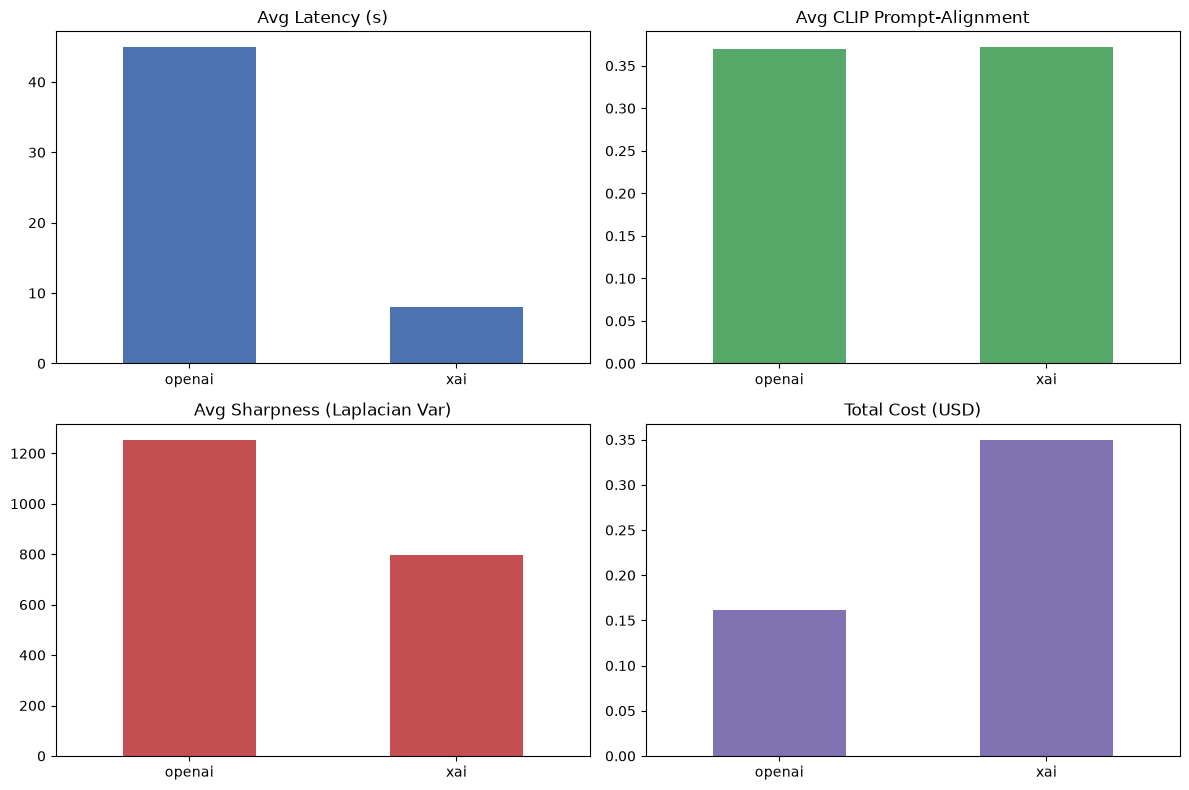

In [75]:
# === 10. Visual comparison charts ===

if not success_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    summary["avg_latency_s"].plot(kind="bar", ax=axes[0, 0], title="Avg Latency (s)", color="#4C72B0")
    summary["avg_clip_alignment"].plot(kind="bar", ax=axes[0, 1], title="Avg CLIP Prompt-Alignment", color="#55A868")
    summary["avg_sharpness"].plot(kind="bar", ax=axes[1, 0], title="Avg Sharpness (Laplacian Var)", color="#C44E52")
    summary["total_cost_usd"].plot(kind="bar", ax=axes[1, 1], title="Total Cost (USD)", color="#8172B2")

    for ax in axes.flat:
        ax.set_xlabel("")
        ax.tick_params(axis='x', rotation=0)

    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/comparison_charts.png", dpi=150)
    plt.show()
else:
    print("No successful generations to plot yet — add valid API keys and re-run.")


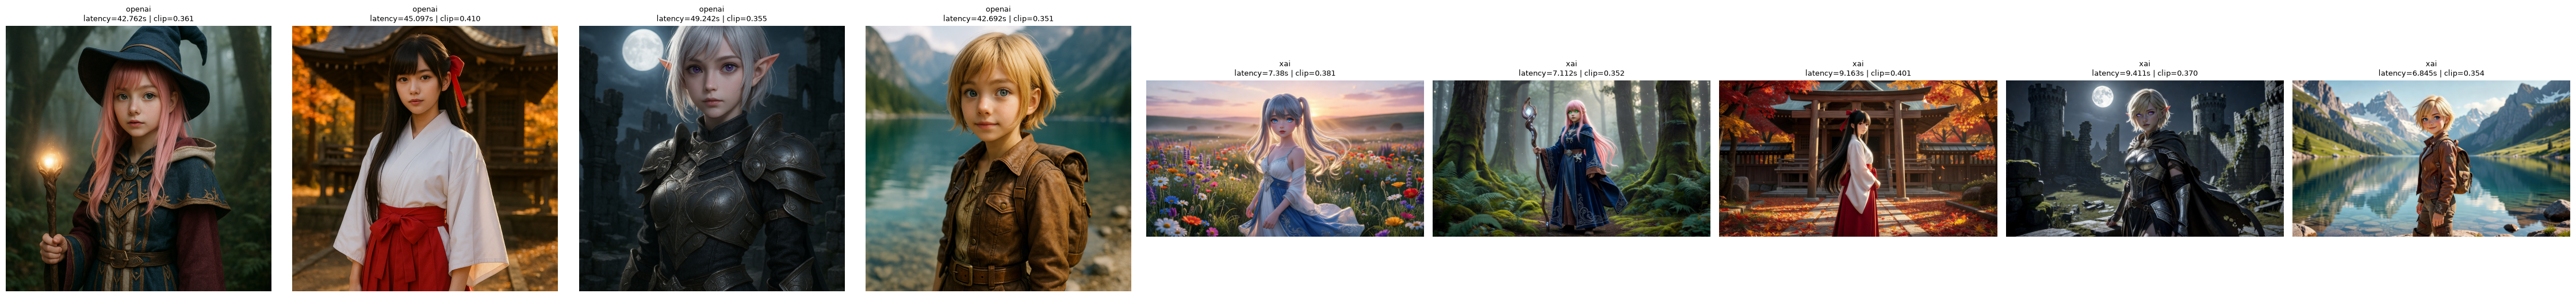

In [76]:
# === 11. Side-by-side image grid for visual eyeballing ===

if not success_df.empty:
    n = len(success_df)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 2:
        axes = [axes]
    for ax, (_, row) in zip(axes, success_df.iterrows()):
        img = Image.open(row["image_path"])
        ax.imshow(img)
        ax.set_title(f'{row["provider"]}\nlatency={row["latency_s"]}s | clip={row["clip_alignment"]:.3f}', fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


# Tugas

Cobalah evaluasi performa pilihan model-model lainnya pada dataset diatas 